# **Diabetes Classifier | EDA & ML**

In [2]:
  #created by Rafi adrian

import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")
import missingno as msno

In [4]:
# 1. Mount Google Drive dulu
from google.colab import drive
drive.mount('/content/drive')

# 2. Baca file dari Google Drive
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/2TI4_data-science/diabetes-classifier/diabetes_prediction_dataset.csv")
df

Mounted at /content/drive


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


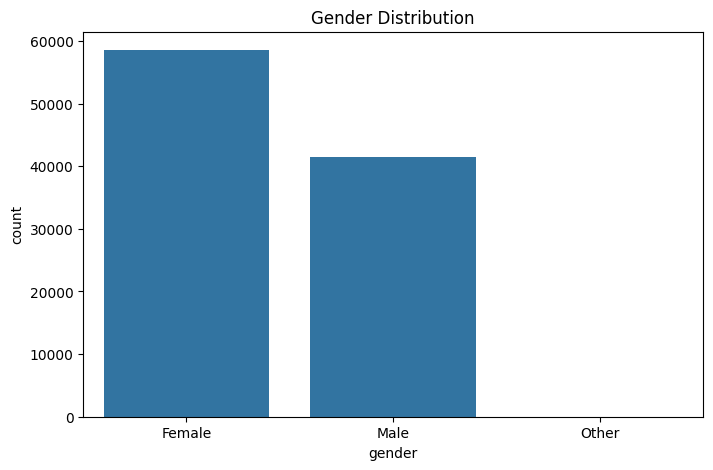

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()


In [8]:
#Masirol Walfaizin

df["gender"].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


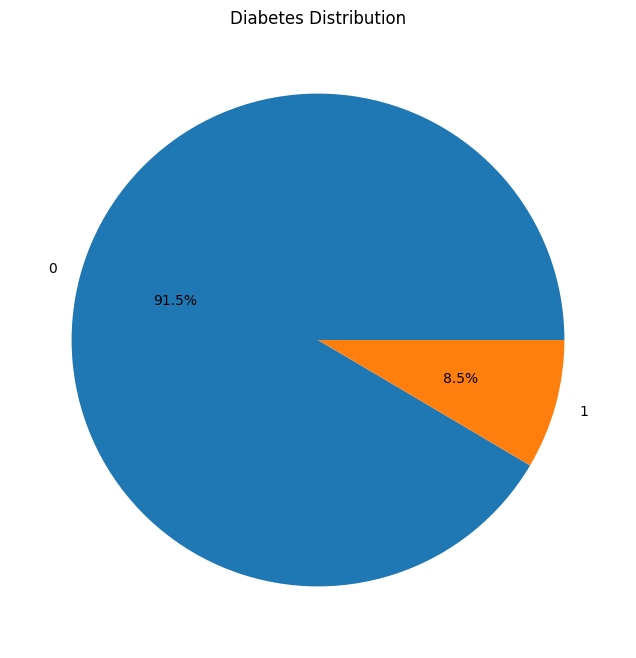

In [9]:
diabetes_counts = df['diabetes'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(diabetes_counts, labels=diabetes_counts.index, autopct='%1.1f%%')
plt.title("Diabetes Distribution")
plt.show()

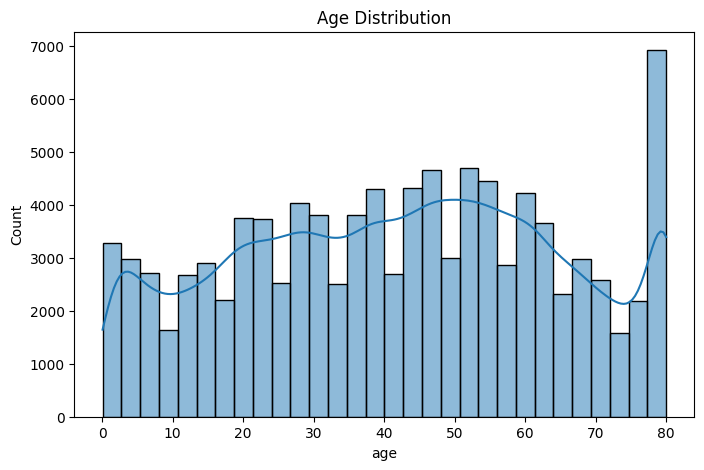

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


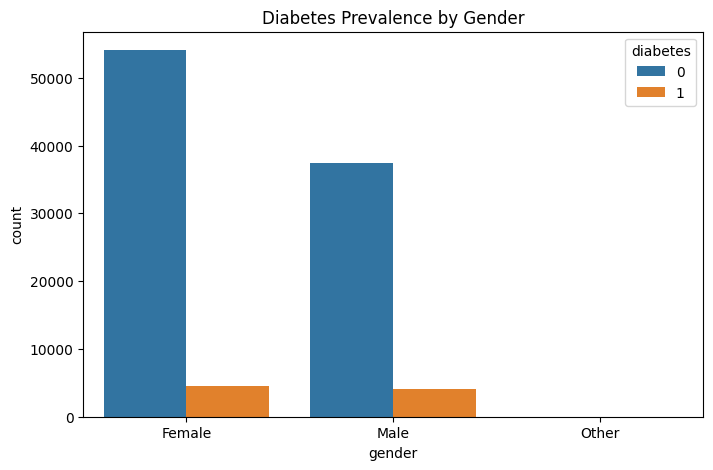

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', hue='diabetes')
plt.title("Diabetes Prevalence by Gender")
plt.show()

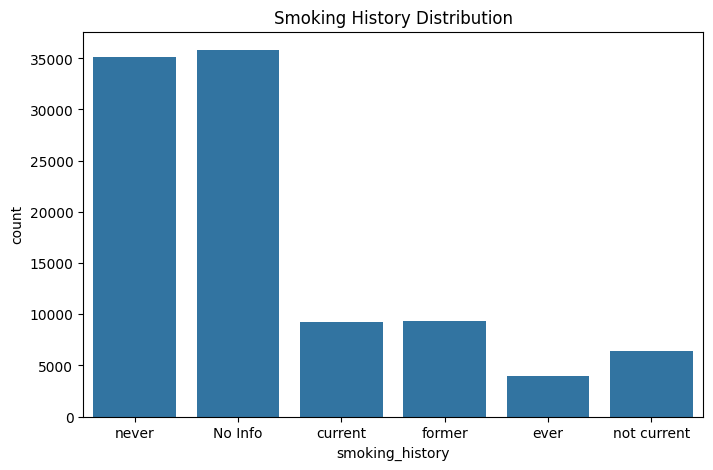

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='smoking_history')
plt.title("Smoking History Distribution")
plt.show()

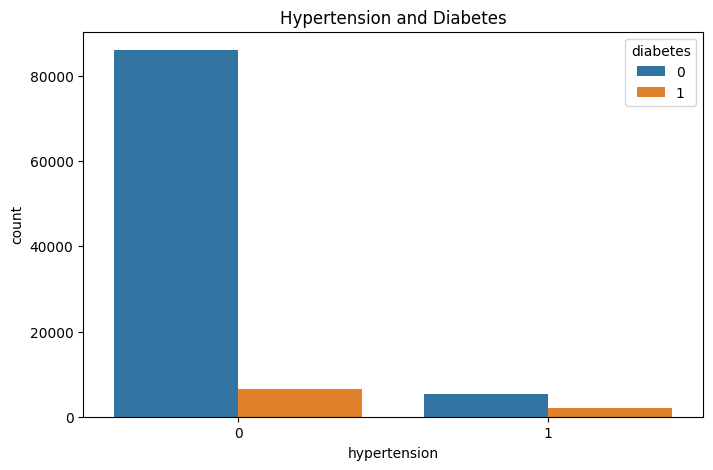

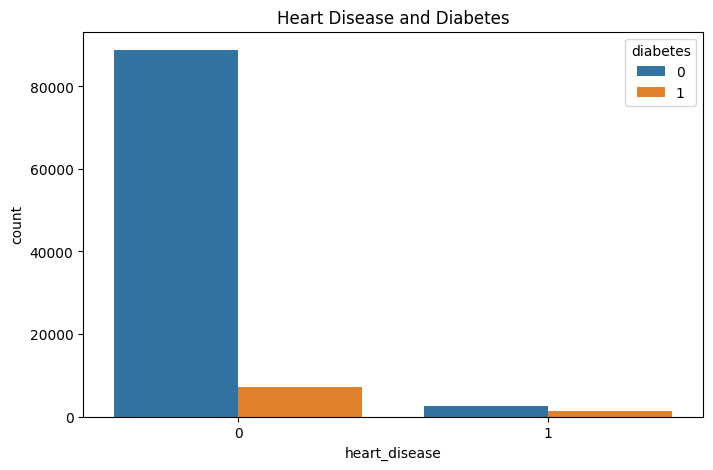

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='hypertension', hue='diabetes')
plt.title("Hypertension and Diabetes")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='heart_disease', hue='diabetes')
plt.title("Heart Disease and Diabetes")
plt.show()

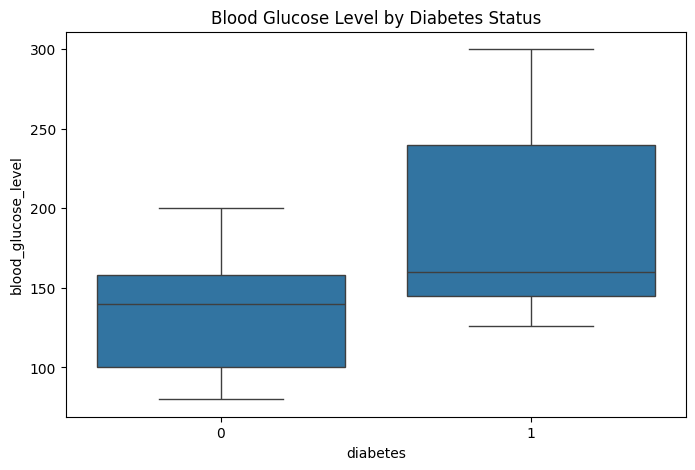

In [14]:
#updated by Rafi Adrian

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level')
plt.title("Blood Glucose Level by Diabetes Status")
plt.show()

In [15]:
df["smoking_history"].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


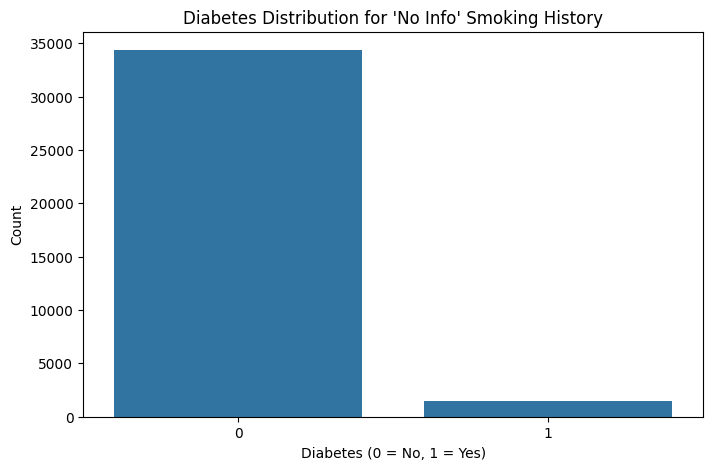

In [16]:
no_info_diabetes = df[df['smoking_history'] == "No Info"]
plt.figure(figsize=(8, 5))
sns.countplot(data=no_info_diabetes, x='diabetes')
plt.title("Diabetes Distribution for 'No Info' Smoking History")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [17]:
df['smoking_history'] = df['smoking_history'].map({
    'No Info': 0,
    'never': 0,
    'former': 1,
    'current': 1,
    'not current': 1,
    'ever': 1
})

In [18]:
#updated by raja <3
df['gender'] = df['gender'].map({
    'Female': 0,
    'Other': 0,
    'Male': 1,
})

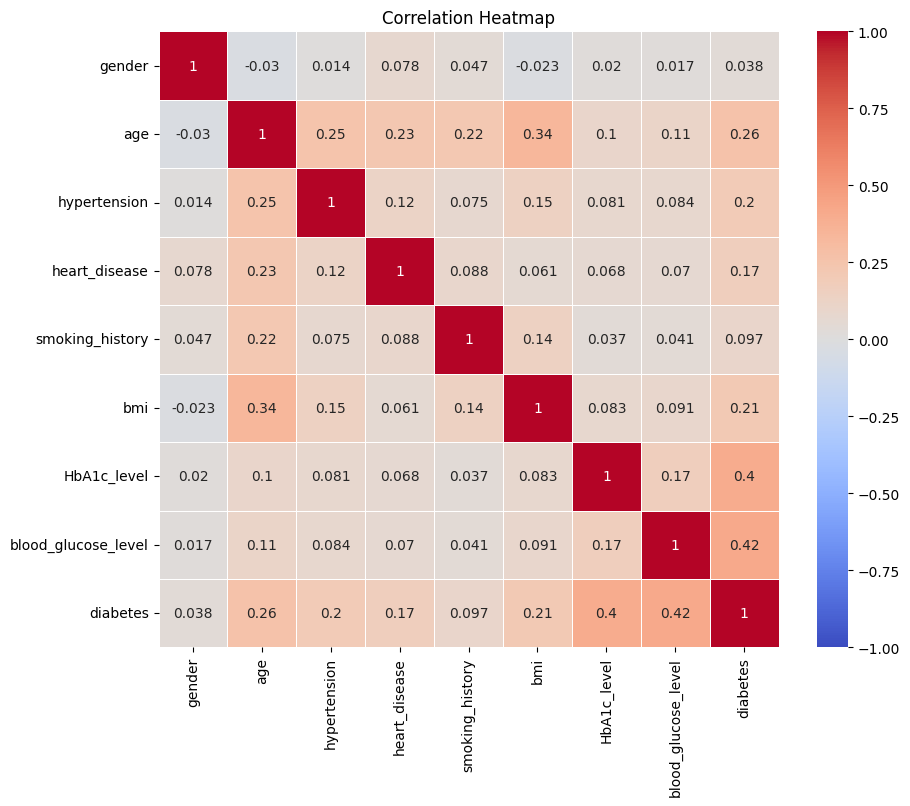

In [19]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
X = df.drop(columns = ["diabetes"])
Y = df["diabetes"].values.reshape(-1, 1)

In [21]:
Y.shape

(100000, 1)

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state= 55)

In [23]:
model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [24]:
model.score(X_train, Y_train)

0.9587125

In [25]:
y_pred = model.predict(X_test)

In [26]:
print(accuracy_score(y_pred, Y_test))

0.96085


In [27]:
print(mean_squared_error(y_pred, Y_test))

0.03915


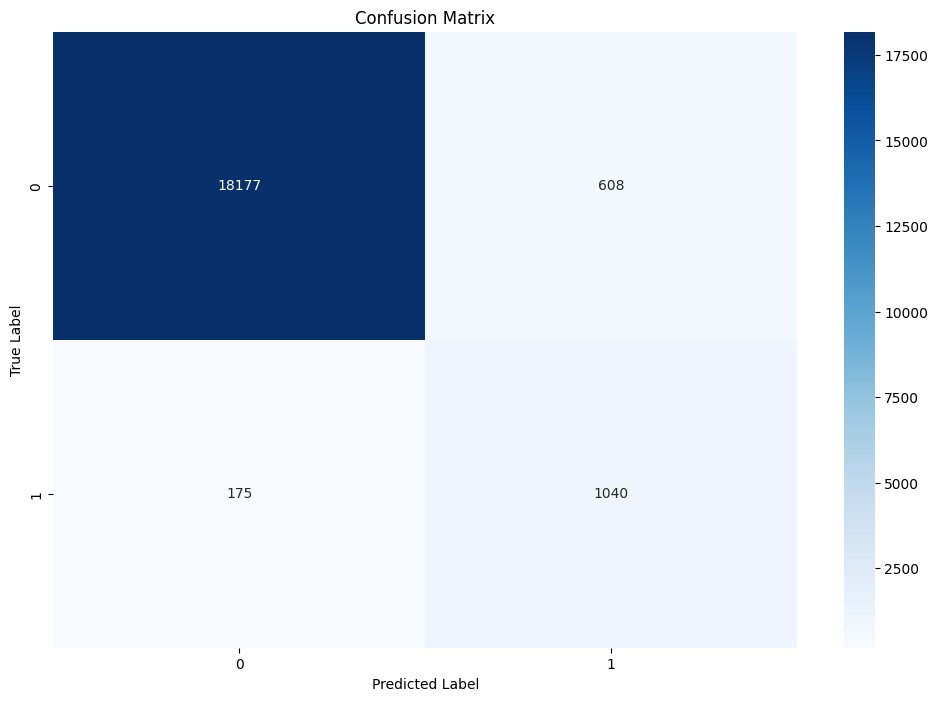

In [28]:
cm = confusion_matrix(y_pred, Y_test)


plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
